In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from umap import UMAP
from sklearn.decomposition import PCA, KernelPCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import RidgeClassifier
import DimensionReduction as dr

#Function to create stratified folds
def create_stratified_folds(X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True)
    folds = []
    for train_index, test_index in skf.split(X, y):
        folds.append((train_index, test_index))
    return folds

def evaluate_knn(X_train, y_train, X_test, y_test):
    param_grid = {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
    knn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=3, scoring='accuracy')
    knn.fit(X_train, y_train)
    y_pred = knn.best_estimator_.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
    return accuracy, report, conf_matrix, knn.best_params_

#Classifiers models (Logistic Regression)

def evaluate_logistic_regression(X_train, y_train, X_test, y_test):
    param_grid = {
        'C': [0.01, 0.1, 1, 10, 100]
    }
    logreg = GridSearchCV(LogisticRegression(max_iter=1000, solver='lbfgs'), param_grid, cv=3, 
                          scoring='accuracy', n_jobs=-1)
    logreg.fit(X_train, y_train)
    y_pred = logreg.best_estimator_.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
    return accuracy, report, conf_matrix, logreg.best_params_

#Classifiers models (Naive Bayes)

def evaluate_naive_bayes(X_train, y_train, X_test, y_test):
    param_grid = {
        'var_smoothing': np.logspace(-12, -1, 12)
    }
    nb = GridSearchCV(GaussianNB(), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
    nb.fit(X_train, y_train)
    y_pred = nb.best_estimator_.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
    return accuracy, report, conf_matrix, nb.best_params_

#Classifiers models (QDA)

def evaluate_qda(X_train, y_train, X_test, y_test):
    param_grid = {
        'reg_param': [0.0, 0.01, 0.1, 0.3, 0.5, 0.7, 1.0]
    }
    qda = GridSearchCV(QuadraticDiscriminantAnalysis(), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
    qda.fit(X_train, y_train)
    y_pred = qda.best_estimator_.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
    return accuracy, report, conf_matrix, qda.best_params_

C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


array([0, 6, 1, ..., 3, 1, 5], shape=(10000,))

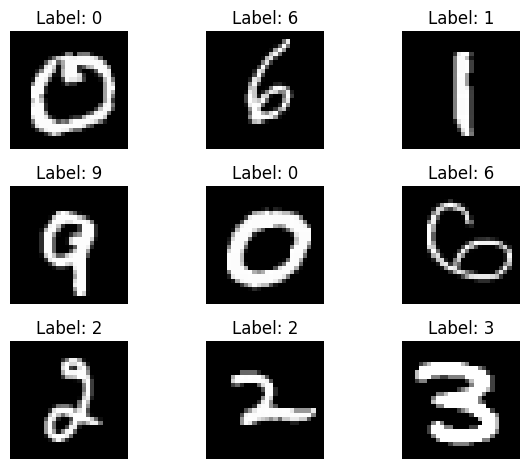

In [2]:

Palette = [
    "#999999", "#E69F00", "#56B4E9", "#009E73",
    "#F0E442", "#0072B2", "#D55E00", "#CC79A7",
    '#377eb8', '#ff7f00', '#4daf4a', '#f781bf', 
    '#a65628', '#984ea3', '#999999', '#e41a1c', 
    '#dede00'
]  # colour-blind friendly palette

PATHIM = "mnist_large/images.csv"
PATHLB = "mnist_large/labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

def scatter_panel(ax, df, x, y, group, title, xlabel=None, ylabel=None, palette=None):
    cats = pd.Categorical(df[group])
    if palette is None:
        palette = Palette[1:1 + len(cats.categories)]
    for i, cat in enumerate(cats.categories):
        mask = df[group] == cat
        ax.scatter(df.loc[mask, x], df.loc[mask, y], s=25, color=palette[i], label=str(cat))
    ax.set_title(title)
    ax.set_xlabel(xlabel if xlabel is not None else x)
    ax.set_ylabel(ylabel if ylabel is not None else y)
    ax.legend()

images = np.array(images)
labels = np.array(labels).ravel()


num_images = len(labels)
#num_sub = 1000
digits_sub = [0,1,2,3,4,5,6,7,8,9]
idx = []
for i,label in enumerate(labels):
    if label in digits_sub:
        idx.append(i)
idx = np.random.permutation(idx)

images_sub = images[idx]
labels_sub = labels[idx]
display(labels_sub)

fig, axes = plt.subplots(3, 3)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(28,28)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()
# Create a test and train set
X_data, x_test_final, Y_data, y_test_final = train_test_split(images_sub, labels_sub, test_size=0.2, stratify=labels_sub)

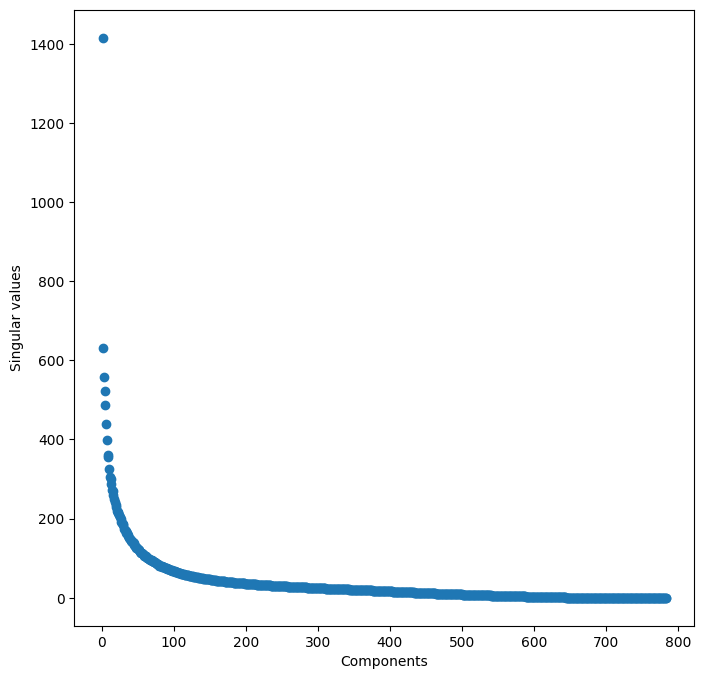

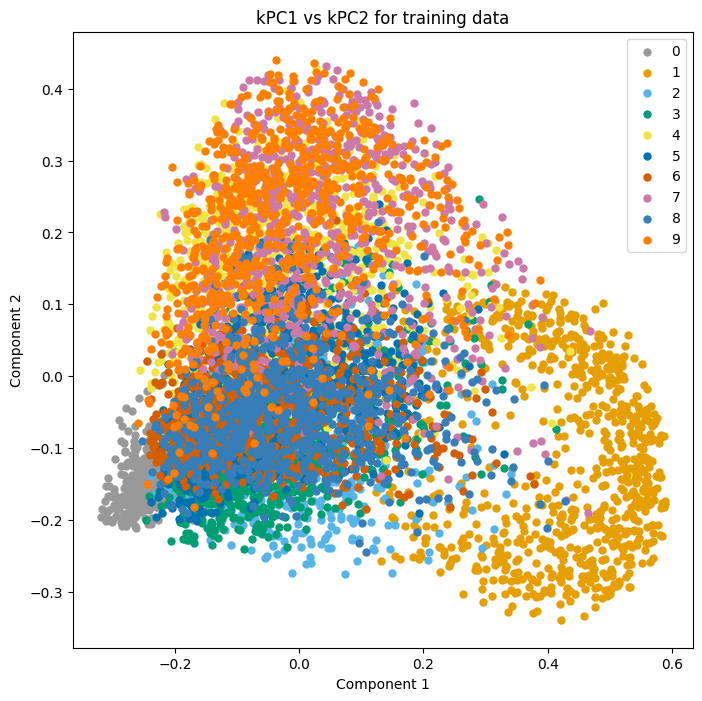

In [3]:
dr.singular_vs_components(X_data,savefig=True)

nf = 20

x_train_kpca,x_test_final_kpca = dr.kpca(X_data,x_test_final,nf,0.002,kernel="rbf",eigen_solver="auto")

kpca_train = pd.DataFrame(x_train_kpca)
kpca_train.columns = [f'Component {i}' for i in range(1, nf+1)]
kpca_train["Labels"] = Y_data

fig, ax = plt.subplots(figsize=(8,8))

scatter_panel(ax, kpca_train, "Component 1", "Component 2", "Labels", title="kPC1 vs kPC2 for training data",palette=Palette)
#fig.savefig("kPC1 vs kPC2 for training data.jpg",format="jpg")

kpca_test_final = pd.DataFrame(x_test_final_kpca)
kpca_test_final.columns = [f'Component {i}' for i in range(1, nf+1)]
kpca_test_final["Labels"] = y_test_final

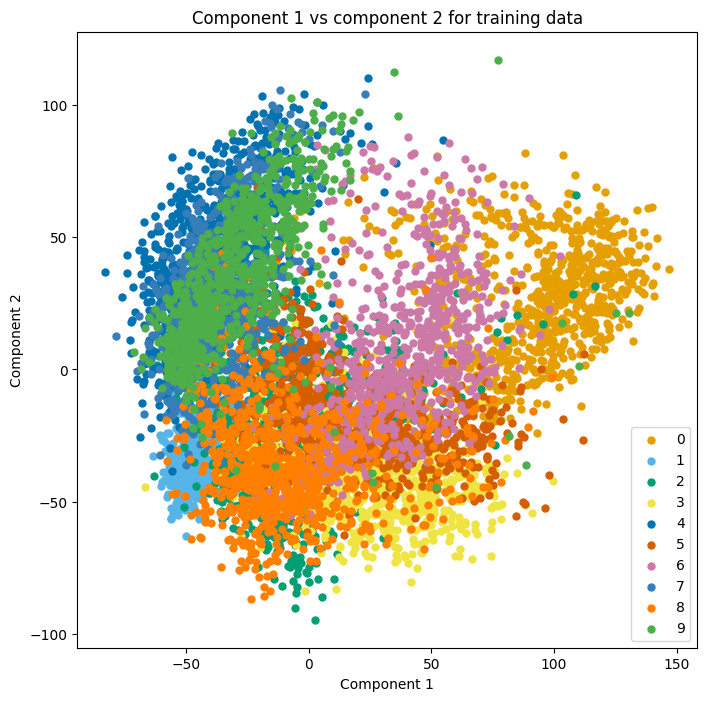

In [4]:
nf = 20

x_train_isom,x_test_final_isom = dr.isom(X_data,x_test_final,nf,5)
isom_train = pd.DataFrame(x_train_isom)
isom_train.columns = [f'Component {i}' for i in range(1, nf+1)]
isom_train["Labels"] = Y_data

fig, ax = plt.subplots(figsize=(8,8))

scatter_panel(ax, isom_train, "Component 1", "Component 2", "Labels", title="Component 1 vs component 2 for training data")
#fig.savefig("Isomap component 1 vs component 2 for training data.jpg",format="jpg")
isom_test_final = pd.DataFrame(x_test_final_isom)
isom_test_final.columns = [f'Component {i}' for i in range(1, nf+1)]
isom_test_final["Labels"] = y_test_final

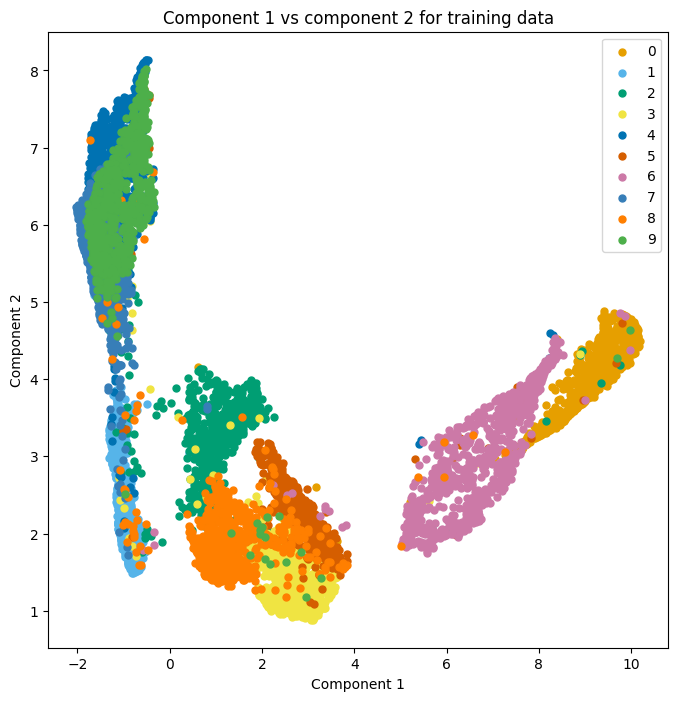

In [6]:
nf = 20

x_train_umap,x_test_final_umap = dr.drumap(X_data,x_test_final,nf,10,min_dist=0.2,randomized=True)
umap_train = pd.DataFrame(x_train_umap)
umap_train.columns = [f'Component {i}' for i in range(1, nf+1)]
umap_train["Labels"] = Y_data

fig, ax = plt.subplots(figsize=(8,8))

scatter_panel(ax, umap_train, "Component 1", "Component 2", "Labels", title="Component 1 vs component 2 for training data")
fig.savefig("UMAP component 1 vs component 2 for training data.jpg",format="jpg")

umap_test_final = pd.DataFrame(x_test_final_umap)
umap_test_final.columns = [f'Component {i}' for i in range(1, nf+1)]
umap_test_final["Labels"] = y_test_final

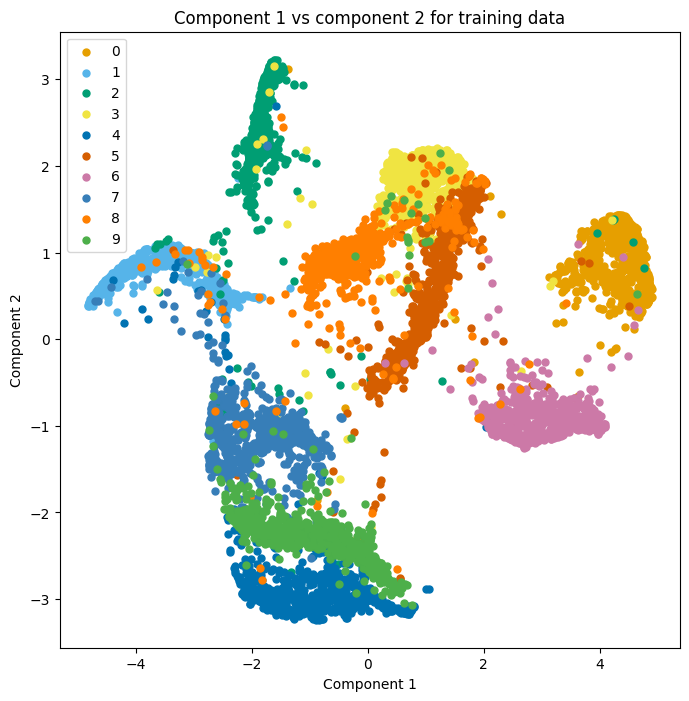

In [7]:
nf = 2

x_train_tsne = dr.tsne(X_data,5,n_components=nf,randomized = True)
tsne_train = pd.DataFrame(x_train_tsne)
tsne_train.columns = [f'Component {i}' for i in range(1, nf+1)]
tsne_train["Labels"] = Y_data

fig, ax = plt.subplots(figsize=(8,8))

scatter_panel(ax, tsne_train, "Component 1", "Component 2", "Labels", title="Component 1 vs component 2 for training data")
fig.savefig("tsne component 1 vs component 2 for training data.jpg",format="jpg")

In [12]:
#Loop through folds for PCA and the 4 different classifiers stated above
folds = create_stratified_folds(X_data, Y_data, n_splits=5)
results = []
for fold_idx, (train_index, test_index) in enumerate(folds):
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = Y_data[train_index], Y_data[test_index]
    
    #Renaming to fit old code convention, standardization occurs at the dimension reduction.
    X_train_scaled, X_test_scaled = X_train, X_test

    nf = 20
    #Apply dimensionality reduction techniques and evaluate classifiers for each fold
    X_train_kpca, X_test_kpca = dr.kpca(X_train_scaled, X_test_scaled, n_components=nf, bandwidth=0.002,kernel="rbf")
    X_train_isom, X_test_isom = dr.isom(X_train_scaled, X_test_scaled, n_components=nf, n_neighbors=5)
    X_train_umap, X_test_umap = dr.drumap(X_train_scaled, X_test_scaled, n_components=nf, n_neighbors=10, min_dist=0.2, randomized=True)
    
    # Evaluate KNN
    knn_kpca_accuracy, knn_kpca_report, knn_kpca_conf_matrix, knn_kpca_params = evaluate_knn(X_train_kpca, y_train, X_test_kpca, y_test)
    knn_isom_accuracy, knn_isom_report, knn_isom_conf_matrix, knn_isom_params = evaluate_knn(X_train_isom, y_train, X_test_isom, y_test)
    knn_umap_accuracy, knn_umap_report, knn_umap_conf_matrix, knn_umap_params = evaluate_knn(X_train_umap, y_train, X_test_umap, y_test)
    
    # Evaluate Logistic Regression
    logreg_kpca_accuracy, logreg_kpca_report, logreg_kpca_conf_matrix, logreg_kpca_params = evaluate_logistic_regression(X_train_kpca, y_train, X_test_kpca, y_test)
    logreg_isom_accuracy, logreg_isom_report, logreg_isom_conf_matrix, logreg_isom_params = evaluate_logistic_regression(X_train_isom, y_train, X_test_isom, y_test)
    logreg_umap_accuracy, logreg_umap_report, logreg_umap_conf_matrix, logreg_umap_params = evaluate_logistic_regression(X_train_umap, y_train, X_test_umap, y_test)
    
    # Evaluate Naive Bayes
    nb_kpca_accuracy, nb_kpca_report, nb_kpca_conf_matrix, nb_kpca_params = evaluate_naive_bayes(X_train_kpca, y_train, X_test_kpca, y_test)
    nb_isom_accuracy, nb_isom_report, nb_isom_conf_matrix, nb_isom_params = evaluate_naive_bayes(X_train_isom, y_train, X_test_isom, y_test)
    nb_umap_accuracy, nb_umap_report, nb_umap_conf_matrix, nb_umap_params = evaluate_naive_bayes(X_train_umap, y_train, X_test_umap, y_test)

    # Evaluate QDA
    qda_kpca_accuracy, qda_kpca_report, qda_kpca_conf_matrix, qda_kpca_params = evaluate_qda(X_train_kpca, y_train, X_test_kpca, y_test)
    qda_isom_accuracy, qda_isom_report, qda_isom_conf_matrix, qda_isom_params = evaluate_qda(X_train_isom, y_train, X_test_isom, y_test)
    qda_umap_accuracy, qda_umap_report, qda_umap_conf_matrix, qda_umap_params = evaluate_qda(X_train_umap, y_train, X_test_umap, y_test)

    
    # Store results
    results.append({
        'fold': fold_idx,
        'knn_kpca_accuracy': knn_kpca_accuracy,
        'knn_isom_accuracy': knn_isom_accuracy,
        'knn_umap_accuracy': knn_umap_accuracy,
        'logreg_kpca_accuracy': logreg_kpca_accuracy,
        'logreg_isom_accuracy': logreg_isom_accuracy,
        'logreg_umap_accuracy': logreg_umap_accuracy,
        'nb_kpca_accuracy': nb_kpca_accuracy,
        'nb_isom_accuracy': nb_isom_accuracy,
        'nb_umap_accuracy': nb_umap_accuracy,
        'qda_kpca_accuracy': qda_kpca_accuracy,
        'qda_isom_accuracy': qda_isom_accuracy,
        'qda_umap_accuracy': qda_umap_accuracy,
        'knn_kpca_report': knn_kpca_report,
        'knn_isom_report': knn_isom_report,
        'knn_umap_report': knn_umap_report,
        'logreg_kpca_report': logreg_kpca_report,
        'logreg_isom_report': logreg_isom_report,
        'logreg_umap_report': logreg_umap_report,
        'nb_kpca_report': nb_kpca_report,
        'nb_isom_report': nb_isom_report,
        'nb_umap_report': nb_umap_report,
        'qda_kpca_report': qda_kpca_report,
        'qda_isom_report': qda_isom_report,
        'qda_umap_report': qda_umap_report,
        'knn_kpca_conf_matrix': knn_kpca_conf_matrix,
        'knn_isom_conf_matrix': knn_isom_conf_matrix,
        'knn_umap_conf_matrix': knn_umap_conf_matrix,
        'logreg_kpca_conf_matrix': logreg_kpca_conf_matrix,
        'logreg_isom_conf_matrix': logreg_isom_conf_matrix,
        'logreg_umap_conf_matrix': logreg_umap_conf_matrix,
        'nb_kpca_conf_matrix': nb_kpca_conf_matrix,
        'nb_isom_conf_matrix': nb_isom_conf_matrix,
        'nb_umap_conf_matrix': nb_umap_conf_matrix,
        'qda_kpca_conf_matrix': qda_kpca_conf_matrix,
        'qda_isom_conf_matrix': qda_isom_conf_matrix,
        'qda_umap_conf_matrix': qda_umap_conf_matrix,
        'knn_kpca_best_params': knn_kpca_params,
        'knn_isom_best_params': knn_isom_params,
        'knn_umap_best_params': knn_umap_params,
        'logreg_kpca_best_params': logreg_kpca_params,
        'logreg_isom_best_params': logreg_isom_params,
        'logreg_umap_best_params': logreg_umap_params,
        'nb_kpca_best_params': nb_kpca_params,
        'nb_isom_best_params': nb_isom_params,
        'nb_umap_best_params': nb_umap_params,
        'qda_kpca_best_params': qda_kpca_params,
        'qda_isom_best_params': qda_isom_params,
        'qda_umap_best_params': qda_umap_params
    })

C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
3 fits failed out of a total of 21.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about th

In [36]:
from collections import Counter
knn_kpca_params_list = [r['knn_kpca_best_params'] for r in results]
knn_isom_params_list = [r['knn_isom_best_params'] for r in results]
knn_umap_params_list = [r['knn_umap_best_params'] for r in results]

logreg_kpca_params_list = [r['logreg_kpca_best_params'] for r in results]
logreg_isom_params_list = [r['logreg_isom_best_params'] for r in results]
logreg_umap_params_list = [r['logreg_umap_best_params'] for r in results]

nb_kpca_params_list = [r['nb_kpca_best_params'] for r in results]
nb_isom_params_list = [r['nb_isom_best_params'] for r in results]
nb_umap_params_list = [r['nb_umap_best_params'] for r in results]

qda_kpca_params_list = [r['qda_kpca_best_params'] for r in results]
qda_isom_params_list = [r['qda_isom_best_params'] for r in results]
qda_umap_params_list = [r['qda_umap_best_params'] for r in results]

most_common_knn_kpca_params = Counter(tuple(sorted(params.items())) for params in knn_kpca_params_list).most_common(1)
most_common_knn_isom_params = Counter(tuple(sorted(params.items())) for params in knn_isom_params_list).most_common(1)
most_common_knn_umap_params = Counter(tuple(sorted(params.items())) for params in knn_umap_params_list).most_common(1)
most_common_logreg_kpca_params = Counter(tuple(sorted(params.items())) for params in logreg_kpca_params_list).most_common(1)
most_common_logreg_isom_params = Counter(tuple(sorted(params.items())) for params in logreg_isom_params_list).most_common(1)
most_common_logreg_umap_params = Counter(tuple(sorted(params.items())) for params in logreg_umap_params_list).most_common(1)
most_common_nb_kpca_params = Counter(tuple(sorted(params.items())) for params in nb_kpca_params_list).most_common(1)
most_common_nb_isom_params = Counter(tuple(sorted(params.items())) for params in nb_isom_params_list).most_common(1)
most_common_nb_umap_params = Counter(tuple(sorted(params.items())) for params in nb_umap_params_list).most_common(1)
most_common_qda_kpca_params = Counter(tuple(sorted(params.items())) for params in qda_kpca_params_list).most_common(1)
most_common_qda_isom_params = Counter(tuple(sorted(params.items())) for params in qda_isom_params_list).most_common(1)
most_common_qda_umap_params = Counter(tuple(sorted(params.items())) for params in qda_umap_params_list).most_common(1)
print(f"Most common KNN KPCA hyperparameters: {most_common_knn_kpca_params}")
print(f"Most common KNN ISOM hyperparameters: {most_common_knn_isom_params}")
print(f"Most common KNN UMAP hyperparameters: {most_common_knn_umap_params}")
print(f"Most common Logistic Regression KPCA hyperparameters: {most_common_logreg_kpca_params}")
print(f"Most common Logistic Regression ISOM hyperparameters: {most_common_logreg_isom_params}")
print(f"Most common Logistic Regression UMAP hyperparameters: {most_common_logreg_umap_params}")
print(f"Most common Naive Bayes KPCA hyperparameters: {most_common_nb_kpca_params}")
print(f"Most common Naive Bayes ISOM hyperparameters: {most_common_nb_isom_params}")
print(f"Most common Naive Bayes UMAP hyperparameters: {most_common_nb_umap_params}")
print(f"Most common QDA KPCA hyperparameters: {most_common_qda_kpca_params}")
print(f"Most common QDA ISOM hyperparameters: {most_common_qda_isom_params}")
print(f"Most common QDA UMAP hyperparameters: {most_common_qda_umap_params}")

Most common KNN KPCA hyperparameters: [((('metric', 'euclidean'), ('n_neighbors', 5), ('weights', 'distance')), 4)]
Most common KNN ISOM hyperparameters: [((('metric', 'euclidean'), ('n_neighbors', 5), ('weights', 'distance')), 3)]
Most common KNN UMAP hyperparameters: [((('metric', 'manhattan'), ('n_neighbors', 5), ('weights', 'distance')), 2)]
Most common Logistic Regression KPCA hyperparameters: [((('C', 100),), 5)]
Most common Logistic Regression ISOM hyperparameters: [((('C', 0.01),), 3)]
Most common Logistic Regression UMAP hyperparameters: [((('C', 100),), 5)]
Most common Naive Bayes KPCA hyperparameters: [((('var_smoothing', np.float64(0.01)),), 2)]
Most common Naive Bayes ISOM hyperparameters: [((('var_smoothing', np.float64(0.01)),), 3)]
Most common Naive Bayes UMAP hyperparameters: [((('var_smoothing', np.float64(1e-12)),), 3)]
Most common QDA KPCA hyperparameters: [((('reg_param', 0.01),), 5)]
Most common QDA ISOM hyperparameters: [((('reg_param', 0.0),), 3)]
Most common QD

In [37]:
#Print mean accuracy for each classsifier and dimensionality reduction technique across folds
mean_knn_kpca_accuracy = np.mean([r['knn_kpca_accuracy'] for r in results])
mean_knn_isom_accuracy = np.mean([r['knn_isom_accuracy'] for r in results])
mean_knn_umap_accuracy = np.mean([r['knn_umap_accuracy'] for r in results])
mean_logreg_kpca_accuracy = np.mean([r['logreg_kpca_accuracy'] for r in results])
mean_logreg_isom_accuracy = np.mean([r['logreg_isom_accuracy'] for r in results])
mean_logreg_umap_accuracy = np.mean([r['logreg_umap_accuracy'] for r in results])
mean_nb_kpca_accuracy = np.mean([r['nb_kpca_accuracy'] for r in results])
mean_nb_isom_accuracy = np.mean([r['nb_isom_accuracy'] for r in results])
mean_nb_umap_accuracy = np.mean([r['nb_umap_accuracy'] for r in results])
mean_qda_kpca_accuracy = np.mean([r['qda_kpca_accuracy'] for r in results])
mean_qda_isom_accuracy = np.mean([r['qda_isom_accuracy'] for r in results])
mean_qda_umap_accuracy = np.mean([r['qda_umap_accuracy'] for r in results])
print(f"Mean KNN KPCA Accuracy: {mean_knn_kpca_accuracy:.4f}")
print(f"Mean KNN ISOM Accuracy: {mean_knn_isom_accuracy:.4f}")
print(f"Mean KNN UMAP Accuracy: {mean_knn_umap_accuracy:.4f}")
print(f"Mean Logistic Regression KPCA Accuracy: {mean_logreg_kpca_accuracy:.4f}")
print(f"Mean Logistic Regression ISOM Accuracy: {mean_logreg_isom_accuracy:.4f}")
print(f"Mean Logistic Regression UMAP Accuracy: {mean_logreg_umap_accuracy:.4f}")
print(f"Mean Naive Bayes KPCA Accuracy: {mean_nb_kpca_accuracy:.4f}")
print(f"Mean Naive Bayes ISOM Accuracy: {mean_nb_isom_accuracy:.4f}")
print(f"Mean Naive Bayes UMAP Accuracy: {mean_nb_umap_accuracy:.4f}")
print(f"Mean QDA KPCA Accuracy: {mean_qda_kpca_accuracy:.4f}")
print(f"Mean QDA ISOM Accuracy: {mean_qda_isom_accuracy:.4f}")
print(f"Mean QDA UMAP Accuracy: {mean_qda_umap_accuracy:.4f}")

Mean KNN KPCA Accuracy: 0.9359
Mean KNN ISOM Accuracy: 0.9246
Mean KNN UMAP Accuracy: 0.9197
Mean Logistic Regression KPCA Accuracy: 0.8695
Mean Logistic Regression ISOM Accuracy: 0.9235
Mean Logistic Regression UMAP Accuracy: 0.9169
Mean Naive Bayes KPCA Accuracy: 0.8191
Mean Naive Bayes ISOM Accuracy: 0.8971
Mean Naive Bayes UMAP Accuracy: 0.8964
Mean QDA KPCA Accuracy: 0.8830
Mean QDA ISOM Accuracy: 0.9261
Mean QDA UMAP Accuracy: 0.9171


kNN testing results:
Accuracy: 0.9360


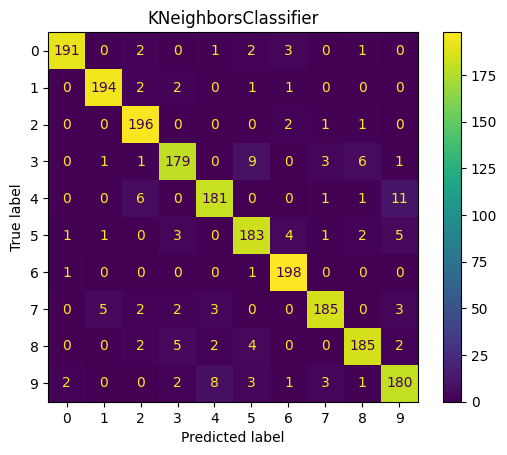

Logistic regression testing results:
Accuracy: 0.9275


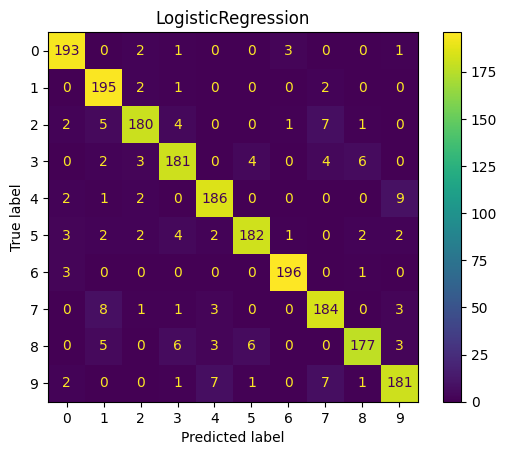

Naive Bayes regression testing results:
Accuracy: 0.8935


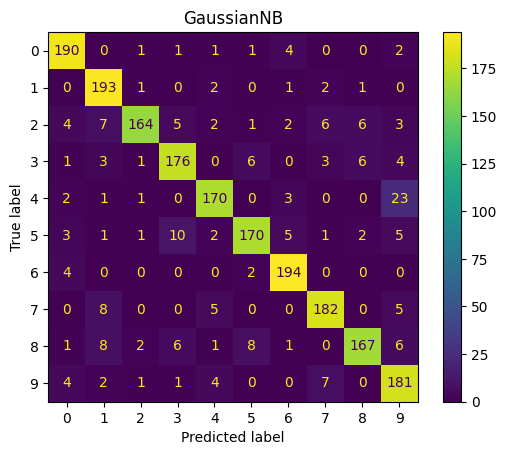

QDA testing results:
Accuracy: 0.8935


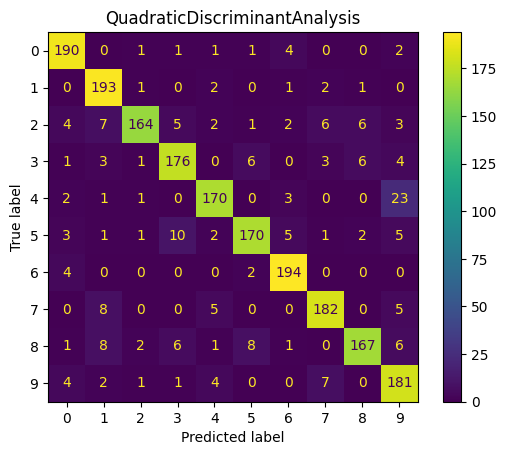

In [53]:
knn_final = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='distance')
logreg_final = LogisticRegression(C=0.01,max_iter=1000)
nb_final = GaussianNB(var_smoothing=0.01)
qda_final = QuadraticDiscriminantAnalysis(reg_param=0.0)

knn_final.fit(x_train_kpca,Y_data)
y_pred_knn = knn_final.predict(x_test_final_kpca)
print("kNN testing results:")
acc = accuracy_score(y_test_final, y_pred_knn)
cm = confusion_matrix(y_test_final, y_pred_knn)
print(f"Accuracy: {acc:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
disp.ax_.set_title(knn_final.__class__.__name__)
plt.savefig("kNN final confusion matrix.jpg",format="jpg")
plt.show()

logreg_final.fit(x_train_isom,Y_data)
y_pred_logreg = logreg_final.predict(x_test_final_isom)
print("Logistic regression testing results:")
acc = accuracy_score(y_test_final, y_pred_logreg)
cm = confusion_matrix(y_test_final, y_pred_logreg)
print(f"Accuracy: {acc:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
disp.ax_.set_title(logreg_final.__class__.__name__)
plt.savefig("Logistic regression final confusion matrix.jpg",format="jpg")
plt.show()

nb_final.fit(x_train_isom,Y_data)
y_pred_nb = nb_final.predict(x_test_final_isom)
print("Naive Bayes regression testing results:")
acc = accuracy_score(y_test_final, y_pred_nb)
cm = confusion_matrix(y_test_final, y_pred_nb)
print(f"Accuracy: {acc:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
disp.ax_.set_title(nb_final.__class__.__name__)
plt.savefig("Naive Bayes regression final confusion matrix.jpg",format="jpg")
plt.show()

qda_final.fit(x_train_isom,Y_data)
y_pred_qda = qda_final.predict(x_test_final_isom)
print("QDA testing results:")
acc = accuracy_score(y_test_final, y_pred_qda)
cm = confusion_matrix(y_test_final, y_pred_qda)
print(f"Accuracy: {acc:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
disp.ax_.set_title(qda_final.__class__.__name__)
plt.savefig("QDA regression final confusion matrix.jpg",format="jpg")
plt.show()


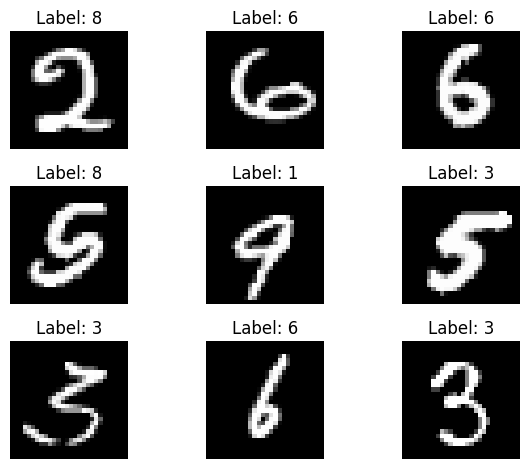

In [61]:
#Misslabel some of the training data
def mislabel_data(X_train, y_train, mislabel_fraction=0.1):
    """
    Randomly mislabels a fraction of the training data.
    """
    n_samples = len(y_train)
    n_mislabel = int(mislabel_fraction * n_samples)
    mislabel_indices = np.random.choice(n_samples, n_mislabel, replace=False)
    y_train_mislabelled = y_train.copy()
    for idx in mislabel_indices:
        original_label = y_train[idx]
        possible_labels = [l for l in np.unique(y_train) if l != original_label]
        y_train_mislabelled[idx] = np.random.choice(possible_labels)
    return X_train, y_train_mislabelled

X_data, Y_data_mislabelled_mild = mislabel_data(X_data,Y_data, mislabel_fraction=0.3)
X_data, Y_data_mislabelled_medium = mislabel_data(X_data,Y_data,mislabel_fraction=0.6)
X_data, Y_data_mislabelled_severe = mislabel_data(X_data,Y_data,mislabel_fraction=0.9)
fig, axes = plt.subplots(3, 3)

for i, ax in enumerate(axes.ravel()):
    img = X_data[i+2].reshape(28,28)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {Y_data_mislabelled_severe[i+2]}")
    ax.axis("off")

plt.tight_layout()

kNN testing results:
Accuracy: 0.9275


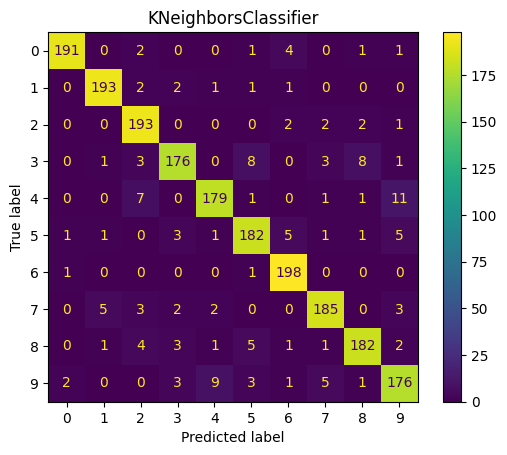

kNN testing results:
Accuracy: 0.8705


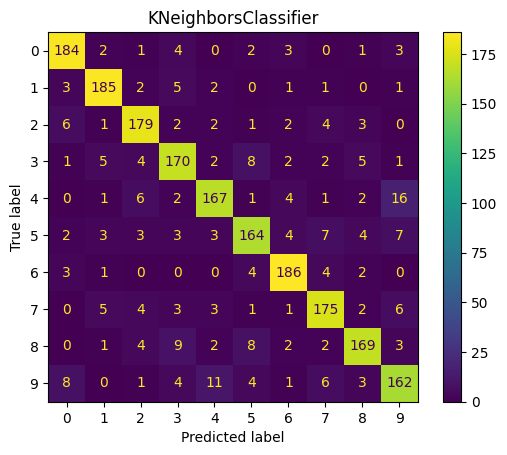

kNN testing results:
Accuracy: 0.5700


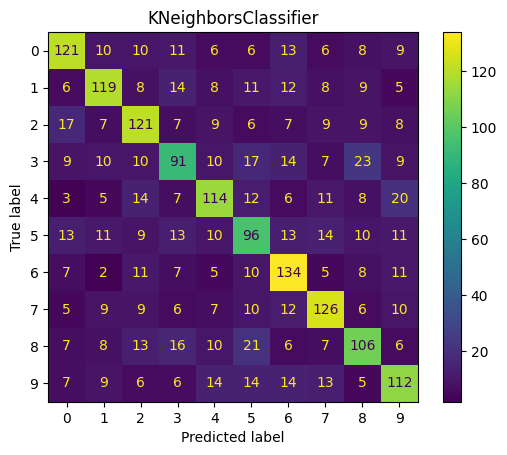

In [64]:
knn_mislabelled_mild = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='distance')
knn_mislabelled_medium = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='distance')
knn_mislabelled_severe = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='distance')

knn_mislabelled_mild.fit(x_train_kpca,Y_data_mislabelled_mild)
y_pred_knn_mislabelled_mild = knn_mislabelled_mild.predict(x_test_final_kpca)
print("kNN testing results:")
acc = accuracy_score(y_test_final, y_pred_knn_mislabelled_mild)
cm = confusion_matrix(y_test_final, y_pred_knn_mislabelled_mild)
print(f"Accuracy: {acc:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
disp.ax_.set_title(knn_mislabelled_mild.__class__.__name__)
#plt.savefig("kNN final confusion matrix.jpg",format="jpg")
plt.show()

knn_mislabelled_medium.fit(x_train_kpca,Y_data_mislabelled_medium)
y_pred_knn_mislabelled_medium = knn_mislabelled_medium.predict(x_test_final_kpca)
print("kNN testing results:")
acc = accuracy_score(y_test_final, y_pred_knn_mislabelled_medium)
cm = confusion_matrix(y_test_final, y_pred_knn_mislabelled_medium)
print(f"Accuracy: {acc:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
disp.ax_.set_title(knn_mislabelled_medium.__class__.__name__)
#plt.savefig("kNN final confusion matrix.jpg",format="jpg")
plt.show()

knn_mislabelled_severe.fit(x_train_kpca,Y_data_mislabelled_severe)
y_pred_knn_mislabelled_severe = knn_mislabelled_severe.predict(x_test_final_kpca)
print("kNN testing results:")
acc = accuracy_score(y_test_final, y_pred_knn_mislabelled_severe)
cm = confusion_matrix(y_test_final, y_pred_knn_mislabelled_severe)
print(f"Accuracy: {acc:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
disp.ax_.set_title(knn_mislabelled_severe.__class__.__name__)
#plt.savefig("kNN final confusion matrix.jpg",format="jpg")
plt.show()

Logreg testing results:
Accuracy: 0.9060


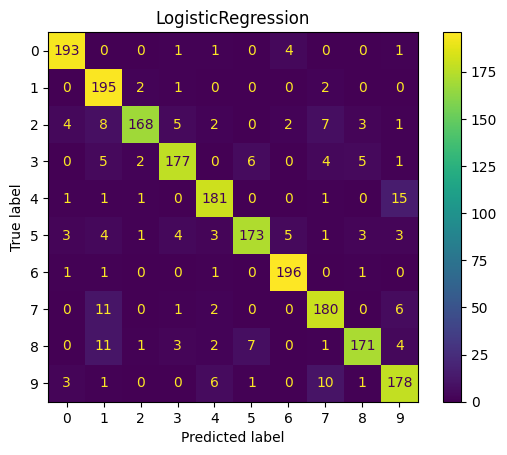

Logreg testing results:
Accuracy: 0.9000


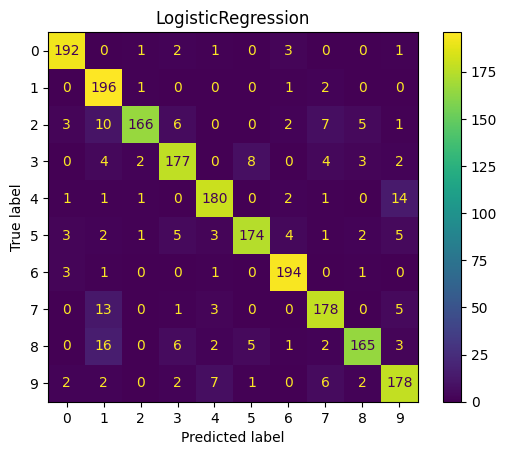

Logreg testing results:
Accuracy: 0.8890


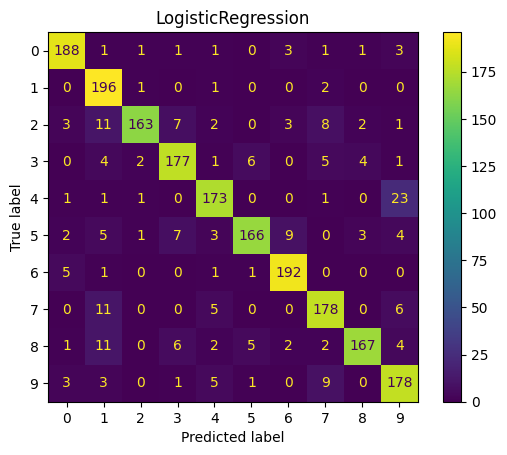

In [68]:
logreg_mislabelled_mild = LogisticRegression(C=0.01,max_iter=1000)
logreg_mislabelled_medium = LogisticRegression(C=0.01,max_iter=1000)
logreg_mislabelled_severe = LogisticRegression(C=0.01,max_iter=1000)

logreg_mislabelled_mild.fit(x_train_isom,Y_data_mislabelled_mild)
y_pred_logreg_mislabelled_mild = logreg_mislabelled_mild.predict(x_test_final_isom)
print("Logreg testing results:")
acc = accuracy_score(y_test_final, y_pred_logreg_mislabelled_mild)
cm = confusion_matrix(y_test_final, y_pred_logreg_mislabelled_mild)
print(f"Accuracy: {acc:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
disp.ax_.set_title(logreg_mislabelled_mild.__class__.__name__)
#plt.savefig("kNN final confusion matrix.jpg",format="jpg")
plt.show()

logreg_mislabelled_medium.fit(x_train_isom,Y_data_mislabelled_medium)
y_pred_logreg_mislabelled_medium = logreg_mislabelled_medium.predict(x_test_final_isom)
print("Logreg testing results:")
acc = accuracy_score(y_test_final, y_pred_logreg_mislabelled_medium)
cm = confusion_matrix(y_test_final, y_pred_logreg_mislabelled_medium)
print(f"Accuracy: {acc:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
disp.ax_.set_title(logreg_mislabelled_medium.__class__.__name__)
#plt.savefig("kNN final confusion matrix.jpg",format="jpg")
plt.show()

logreg_mislabelled_severe.fit(x_train_isom,Y_data_mislabelled_severe)
y_pred_logreg_mislabelled_severe = logreg_mislabelled_severe.predict(x_test_final_isom)
print("Logreg testing results:")
acc = accuracy_score(y_test_final, y_pred_logreg_mislabelled_severe)
cm = confusion_matrix(y_test_final, y_pred_logreg_mislabelled_severe)
print(f"Accuracy: {acc:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
disp.ax_.set_title(logreg_mislabelled_severe.__class__.__name__)
#plt.savefig("kNN final confusion matrix.jpg",format="jpg")
plt.show()

NB testing results:
Accuracy: 0.8870


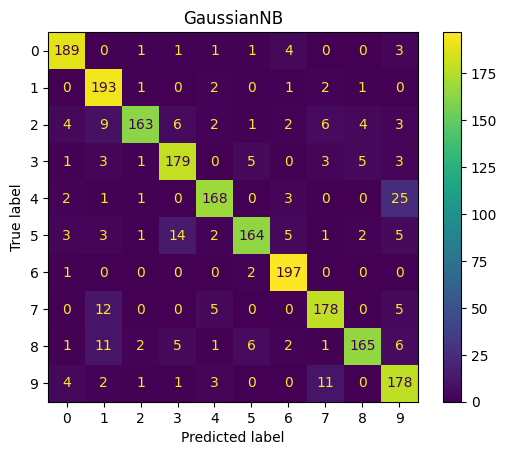

NB testing results:
Accuracy: 0.8845


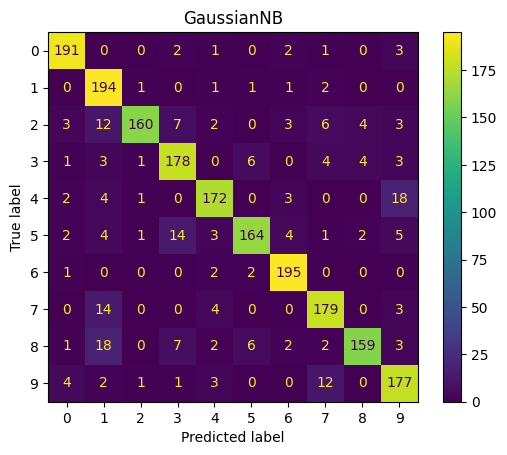

NB testing results:
Accuracy: 0.8705


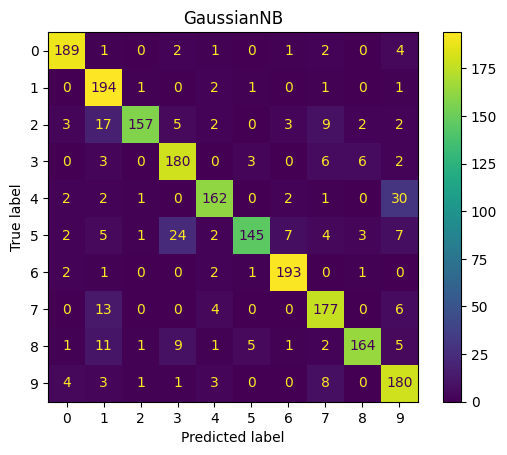

In [69]:
nb_mislabelled_mild = GaussianNB(var_smoothing=0.01)
nb_mislabelled_medium = GaussianNB(var_smoothing=0.01)
nb_mislabelled_severe = GaussianNB(var_smoothing=0.01)



nb_mislabelled_mild.fit(x_train_isom,Y_data_mislabelled_mild)
y_pred_nb_mislabelled_mild = nb_mislabelled_mild.predict(x_test_final_isom)
print("NB testing results:")
acc = accuracy_score(y_test_final, y_pred_nb_mislabelled_mild)
cm = confusion_matrix(y_test_final, y_pred_nb_mislabelled_mild)
print(f"Accuracy: {acc:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
disp.ax_.set_title(nb_mislabelled_mild.__class__.__name__)
#plt.savefig("kNN final confusion matrix.jpg",format="jpg")
plt.show()

nb_mislabelled_medium.fit(x_train_isom,Y_data_mislabelled_medium)
y_pred_nb_mislabelled_medium = nb_mislabelled_medium.predict(x_test_final_isom)
print("NB testing results:")
acc = accuracy_score(y_test_final, y_pred_nb_mislabelled_medium)
cm = confusion_matrix(y_test_final, y_pred_nb_mislabelled_medium)
print(f"Accuracy: {acc:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
disp.ax_.set_title(nb_mislabelled_medium.__class__.__name__)
#plt.savefig("kNN final confusion matrix.jpg",format="jpg")
plt.show()

nb_mislabelled_severe.fit(x_train_isom,Y_data_mislabelled_severe)
y_pred_nb_mislabelled_severe = nb_mislabelled_severe.predict(x_test_final_isom)
print("NB testing results:")
acc = accuracy_score(y_test_final, y_pred_nb_mislabelled_severe)
cm = confusion_matrix(y_test_final, y_pred_nb_mislabelled_severe)
print(f"Accuracy: {acc:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
disp.ax_.set_title(nb_mislabelled_severe.__class__.__name__)
#plt.savefig("kNN final confusion matrix.jpg",format="jpg")
plt.show()

QDA testing results:
Accuracy: 0.9225


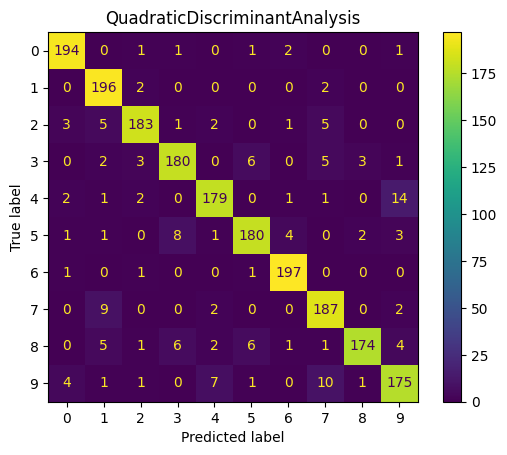

QDA testing results:
Accuracy: 0.9045


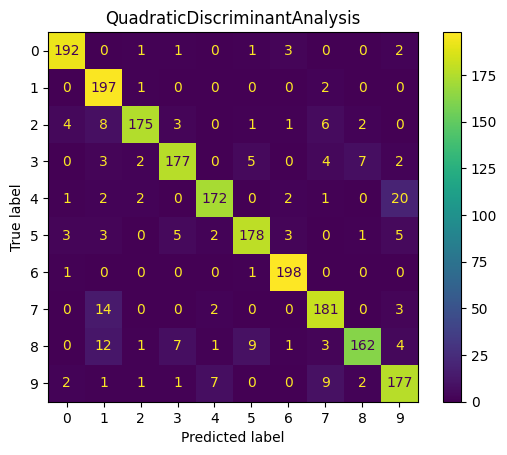

QDA testing results:
Accuracy: 0.8970


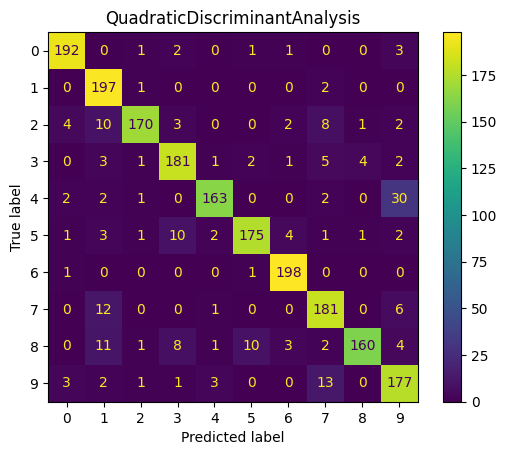

In [71]:
qda_mislabelled_mild = QuadraticDiscriminantAnalysis(reg_param=0.0)
qda_mislabelled_medium = QuadraticDiscriminantAnalysis(reg_param=0.0)
qda_mislabelled_severe = QuadraticDiscriminantAnalysis(reg_param=0.0)


qda_mislabelled_mild.fit(x_train_isom,Y_data_mislabelled_mild)
y_pred_qda_mislabelled_mild = qda_mislabelled_mild.predict(x_test_final_isom)
print("QDA testing results:")
acc = accuracy_score(y_test_final, y_pred_qda_mislabelled_mild)
cm = confusion_matrix(y_test_final, y_pred_qda_mislabelled_mild)
print(f"Accuracy: {acc:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
disp.ax_.set_title(qda_mislabelled_mild.__class__.__name__)
#plt.savefig("kNN final confusion matrix.jpg",format="jpg")
plt.show()

qda_mislabelled_medium.fit(x_train_isom,Y_data_mislabelled_medium)
y_pred_qda_mislabelled_medium = qda_mislabelled_medium.predict(x_test_final_isom)
print("QDA testing results:")
acc = accuracy_score(y_test_final, y_pred_qda_mislabelled_medium)
cm = confusion_matrix(y_test_final, y_pred_qda_mislabelled_medium)
print(f"Accuracy: {acc:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
disp.ax_.set_title(qda_mislabelled_medium.__class__.__name__)
#plt.savefig("kNN final confusion matrix.jpg",format="jpg")
plt.show()

qda_mislabelled_severe.fit(x_train_isom,Y_data_mislabelled_severe)
y_pred_qda_mislabelled_severe = qda_mislabelled_severe.predict(x_test_final_isom)
print("QDA testing results:")
acc = accuracy_score(y_test_final, y_pred_qda_mislabelled_severe)
cm = confusion_matrix(y_test_final, y_pred_qda_mislabelled_severe)
print(f"Accuracy: {acc:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
disp.ax_.set_title(qda_mislabelled_severe.__class__.__name__)
#plt.savefig("kNN final confusion matrix.jpg",format="jpg")
plt.show()

Generating Scree Plot...


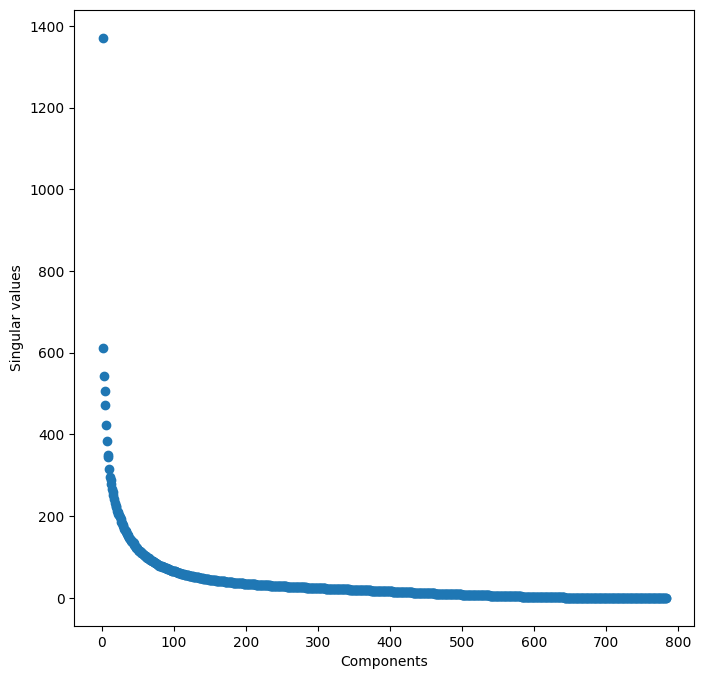

Applying Kernel PCA...


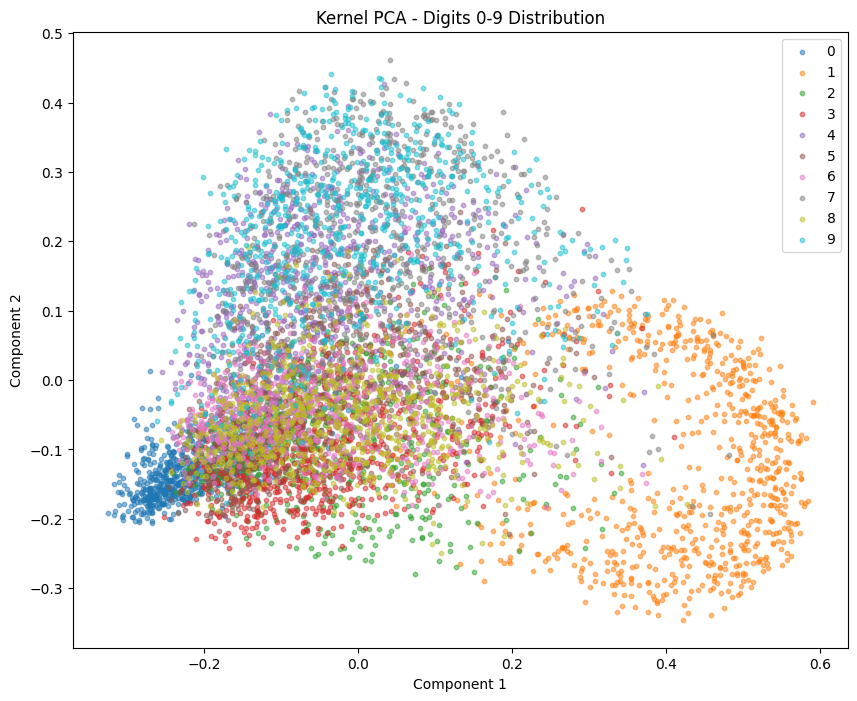

In [8]:
#NN and Random forest code
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import DimensionReduction as dr

PATHIM = 'mnist_large/images.csv'

# What is Images CSV? Each row is one photo of a handwritten digit. The 784 numbers are just pixel brightness values (0 = black, 255 = white).

PATHLB = 'mnist_large/labels.csv'

# Each row is just one number (0–9) telling you what digit that image actually is.

# You have 2000 handwritten digit images (like photos of someone writing 0–9 on paper). Since computers can't read pictures directly, each image is converted into 784 numbers (pixel brightness). That's your images CSV. The labels CSV is simply the answer key — what digit each image actually is.
# Goal: teach a computer to recognize handwritten digits.

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

# The label column was just called "0" by default. This renames it to "label" so it's clearer to work with.

labels = labels.rename(columns={"0":"label"})

images = np.array(images)
labels = np.array(labels).ravel()

# Now using all digits (0-9)
digits = list(range(10))
mask = np.isin(labels, digits)
images_sub = images[mask]
labels_sub = labels[mask]

# Create a test and train set
x_train, x_test, y_train, y_test = train_test_split(images_sub, labels_sub, test_size=0.25, stratify=labels_sub)

# 1. Singular vs Components (Scree Plot)
print("Generating Scree Plot...")
dr.singular_vs_components(x_train, standardize=True)

# 2. Kernel PCA reduction - increasing components for better accuracy on 10 classes
print("Applying Kernel PCA...")
x_train_reduced, x_test_reduced = dr.kpca(x_train, x_test, n_components=10, bandwidth = 0.002)

# Visualization of Kernel PCA (first two components)
plt.figure(figsize=(10, 8))
for digit in digits:
    mask_plot = y_train == digit
    plt.scatter(x_train_reduced[mask_plot, 0], x_train_reduced[mask_plot, 1], label=str(digit), alpha=0.5, s=10)

plt.legend()
plt.title("Kernel PCA - Digits 0-9 Distribution")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

Cross-Validation for Decision Tree
Depth: 5, Split: 2, Leaf: 1 -> CV: 0.6085
Depth: 5, Split: 2, Leaf: 3 -> CV: 0.6088
Depth: 5, Split: 2, Leaf: 5 -> CV: 0.6087
Depth: 5, Split: 5, Leaf: 1 -> CV: 0.6084
Depth: 5, Split: 5, Leaf: 3 -> CV: 0.6088
Depth: 5, Split: 5, Leaf: 5 -> CV: 0.6087
Depth: 5, Split: 10, Leaf: 1 -> CV: 0.6085
Depth: 5, Split: 10, Leaf: 3 -> CV: 0.6088
Depth: 5, Split: 10, Leaf: 5 -> CV: 0.6087
Depth: 10, Split: 2, Leaf: 1 -> CV: 0.7385
Depth: 10, Split: 2, Leaf: 3 -> CV: 0.7335
Depth: 10, Split: 2, Leaf: 5 -> CV: 0.7343
Depth: 10, Split: 5, Leaf: 1 -> CV: 0.7363
Depth: 10, Split: 5, Leaf: 3 -> CV: 0.7335
Depth: 10, Split: 5, Leaf: 5 -> CV: 0.7343
Depth: 10, Split: 10, Leaf: 1 -> CV: 0.7376
Depth: 10, Split: 10, Leaf: 3 -> CV: 0.7341
Depth: 10, Split: 10, Leaf: 5 -> CV: 0.7343
Depth: 15, Split: 2, Leaf: 1 -> CV: 0.7509
Depth: 15, Split: 2, Leaf: 3 -> CV: 0.7435
Depth: 15, Split: 2, Leaf: 5 -> CV: 0.7439
Depth: 15, Split: 5, Leaf: 1 -> CV: 0.7464
Depth: 15, Split: 5, L

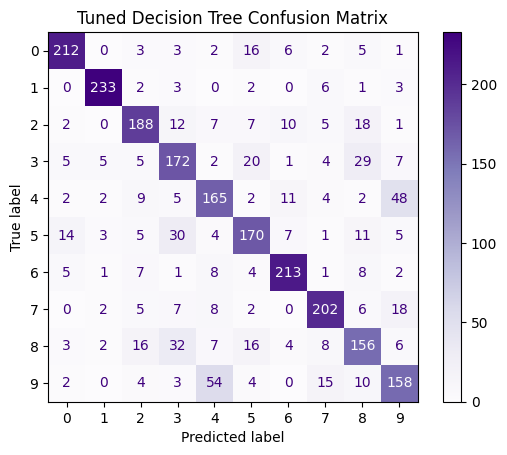

Accuracy of tuned Decision Tree: 74.76%


In [9]:
print("Cross-Validation for Decision Tree")

# Hyperparameter options for Decision Tree
max_depth_options = [5, 10, 15, 20, 25, 30]
min_samples_split_options = [2, 5, 10]
min_samples_leaf_options = [1, 3, 5]

best_score_dt = 0
best_params_dt = None

# Manual search with cross-validation
for depth in max_depth_options:
    for split in min_samples_split_options:
        for leaf in min_samples_leaf_options:
            dt_model = DecisionTreeClassifier(
                random_state=42,  # For reproducibility
                criterion='gini',
                max_depth=depth, # Maximum depth of the tree
                min_samples_split=split, # Minimum number of samples required to split an internal node
                min_samples_leaf=leaf # Minimum number of samples required to be at a leaf node
            )

            scores = cross_val_score(dt_model, x_train_reduced, y_train, cv=5)
            mean_score = np.mean(scores)

            print(f"Depth: {depth}, Split: {split}, Leaf: {leaf} -> CV: {mean_score:.4f}")

            if mean_score > best_score_dt:
                best_score_dt = mean_score
                best_params_dt = {'max_depth': depth, 'min_samples_split': split, 'min_samples_leaf': leaf}

print("\nBest Parameters Found for Decision Tree:")
print(best_params_dt)

# Train final Decision Tree model with best parameters
dt_classifier_tuned_cv = DecisionTreeClassifier(
    random_state=42,
    criterion='gini',
    max_depth=best_params_dt['max_depth'],
    min_samples_split=best_params_dt['min_samples_split'],
    min_samples_leaf=best_params_dt['min_samples_leaf']
)

print("\nTraining Best Decision Tree...")
dt_classifier_tuned_cv.fit(x_train_reduced, y_train)

# Predict on test data
dt_preds_tuned_cv = dt_classifier_tuned_cv.predict(x_test_reduced)

# Confusion matrix
print("\nTuned Decision Tree Classifier Performance (after CV):")
cm_dt_tuned_cv = confusion_matrix(y_test, dt_preds_tuned_cv, labels=digits)
ConfusionMatrixDisplay(cm_dt_tuned_cv, display_labels=digits).plot(cmap='Purples')
plt.title("Tuned Decision Tree Confusion Matrix")
plt.show()

# Accuracy
accuracy_tuned_cv = accuracy_score(y_test, dt_preds_tuned_cv)
print(f"Accuracy of tuned Decision Tree: {accuracy_tuned_cv * 100:.2f}%")

Manual Hyperparameter Tuning...


C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the opti

(128, 128, 64, 32), alpha=0.0001, lr=0.001 → CV: 0.8860


C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the opti

(128, 128, 64, 32), alpha=0.0001, lr=0.0005 → CV: 0.8804


...

C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the opti

(64, 32), alpha=0.01, lr=0.001 → CV: 0.8333


C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the opti

(64, 32), alpha=0.01, lr=0.0005 → CV: 0.8051

Best Parameters Found:
((128, 128, 64, 32), 0.001, 0.001)

Training Best Neural Network...
Iteration 1, loss = 2.23855191
Iteration 2, loss = 1.73854268
Iteration 3, loss = 1.09522663
Iteration 4, loss = 0.78157074
Iteration 5, loss = 0.65634214
Iteration 6, loss = 0.60358283
Iteration 7, loss = 0.56776915
Iteration 8, loss = 0.55032271
Iteration 9, loss = 0.52615868
Iteration 10, loss = 0.51362226
Iteration 11, loss = 0.49660978
Iteration 12, loss = 0.48551679
Iteration 13, loss = 0.46817081
Iteration 14, loss = 0.45562717
Iteration 15, loss = 0.44389057
Iteration 16, loss = 0.43617711
Iteration 17, loss = 0.42714483
Iteration 18, loss = 0.42149486
Iteration 19, loss = 0.40863331
Iteration 20, loss = 0.40487699
Iteration 21, loss = 0.39749345
Iteration 22, loss = 0.39335674
Iteration 23, loss = 0.38727986
Iteration 24, loss = 0.38068189
Iteration 25, loss = 0.37931419
Iteration 26, loss = 0.37258950
Iteration 27, loss = 0.36546511
Iteratio

C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


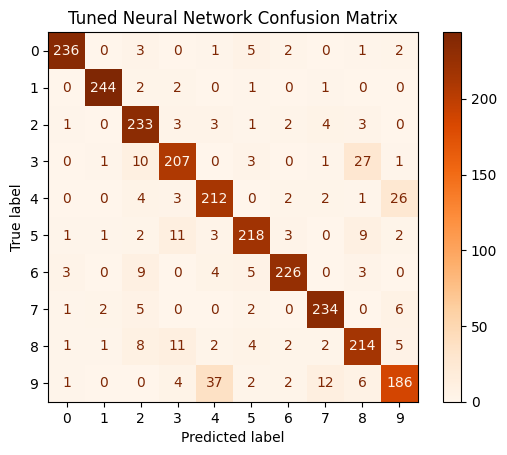

Accuracy: 88.40%


In [10]:
from sklearn.neural_network import MLPClassifier

print("Manual Hyperparameter Tuning...")

# Hyperparameter options
hidden_layers_options = [(128, 128, 64, 32), (128, 64), (64, 32)]
alpha_options = [1e-4, 1e-3, 1e-2]
lr_options = [1e-3, 5e-4]

best_score = 0
best_params = None

# Manual search with cross-validation
for hl in hidden_layers_options:
    for alpha in alpha_options:
        for lr in lr_options:

            model = MLPClassifier(
                random_state=33, # It does the random allocation into the train and test split, then it uses the same one everytime after that.
                max_iter=100, # One round is one full pass through the training data. The model looks at the data, updates its weights, then does another pass if needed.
                verbose=False, # Shows training messages if its True.
                hidden_layer_sizes=hl,  # Layers and the number of neurons in each layer.
                activation='relu', # Chooses the function used inside the hidden layers.
                solver='adam',
                alpha=alpha, # Adds a small penalty to reduce overfitting.
                learning_rate_init=lr,
                early_stopping=False, # Stops training early if validation performance stops improving
                validation_fraction=0.2, # Uses 20% of the training data as test/validation data.
                n_iter_no_change=10  # Stops if the validation score does not improve for 10 rounds.
            )

            scores = cross_val_score(model, x_train_reduced, y_train, cv=5)
            mean_score = np.mean(scores)

            print(f"{hl}, alpha={alpha}, lr={lr} → CV: {mean_score:.4f}")

            if mean_score > best_score:
                best_score = mean_score
                best_params = (hl, alpha, lr)

print("\nBest Parameters Found:")
print(best_params)

# Train final model with best parameters
mlp_classifier = MLPClassifier(
    random_state=33,
    max_iter=100,
    verbose=True,
    hidden_layer_sizes=best_params[0],
    activation='relu',
    solver='adam',
    alpha=best_params[1],
    learning_rate_init=best_params[2],
    early_stopping=False,
    validation_fraction=0.2,
    n_iter_no_change=10
)

print("\nTraining Best Neural Network...")
mlp_classifier.fit(x_train_reduced, y_train)

# Predict
mlp_preds = mlp_classifier.predict(x_test_reduced)

# Confusion matrix
print("\nNeural Network Classifier Performance:")
cm_mlp = confusion_matrix(y_test, mlp_preds, labels=digits)
ConfusionMatrixDisplay(cm_mlp, display_labels=digits).plot(cmap='Oranges')
plt.title("Tuned Neural Network Confusion Matrix")
plt.show()

# Accuracy
accuracy = accuracy_score(y_test, mlp_preds)
print(f"Accuracy: {accuracy * 100:.2f}%")

Running Mislabeling Experiment and generating Confusion Matrices...


C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


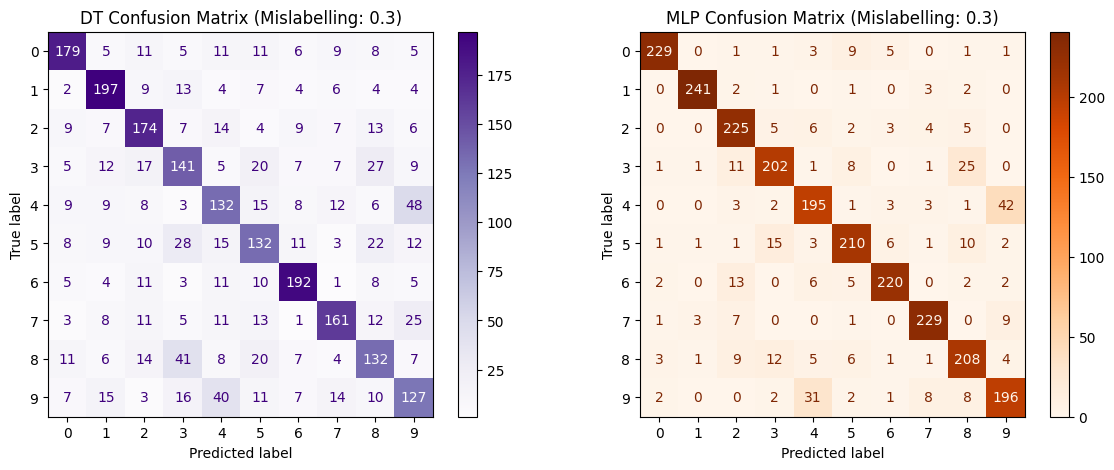

C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


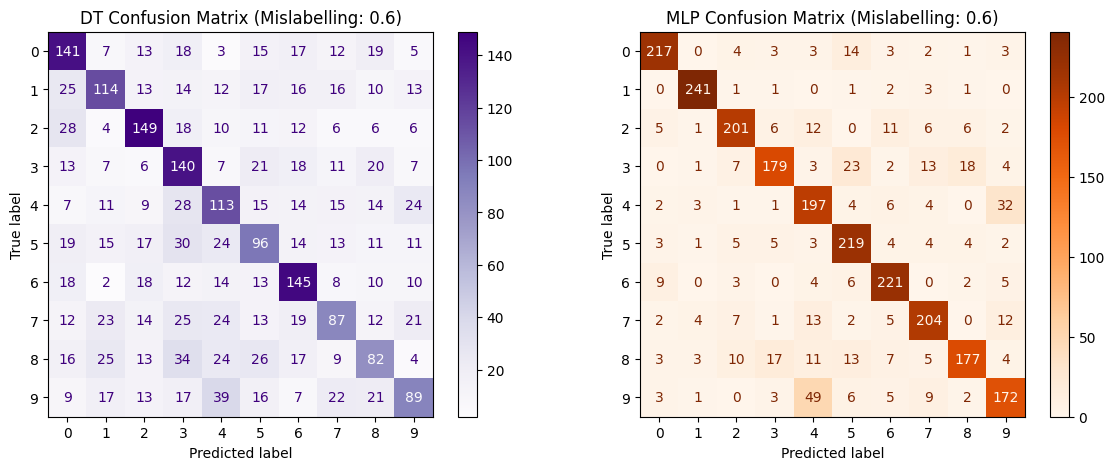

C:\Users\choum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


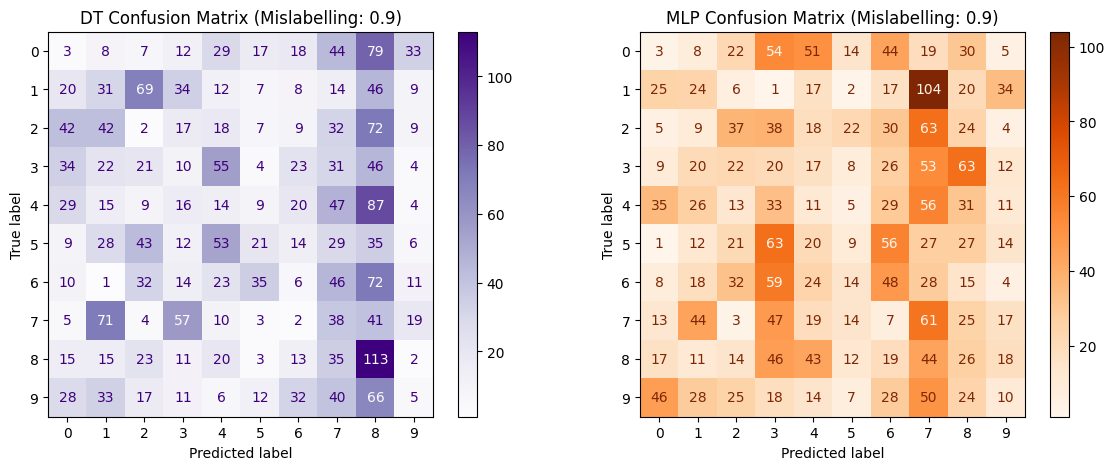

,Mislabel Fraction,DT Accuracy,MLP Accuracy
0,0.3,0.6268,0.8620
1,0.6,0.4624,0.8112
2,0.9,0.0972,0.0996


In [11]:
def mislabel_data(X_train, y_train, mislabel_fraction=0.1):
    """
    Randomly mislabels a fraction of the training data.
    """
    n_samples = len(y_train)
    n_mislabel = int(mislabel_fraction * n_samples)
    mislabel_indices = np.random.choice(n_samples, n_mislabel, replace=False)
    y_train_mislabelled = y_train.copy()
    for idx in mislabel_indices:
        original_label = y_train[idx]
        possible_labels = [l for l in np.unique(y_train) if l != original_label]
        y_train_mislabelled[idx] = np.random.choice(possible_labels)
    return X_train, y_train_mislabelled

# Mislabel experiment levels
mislabel_levels = [0.3, 0.6, 0.9]
results = []

print("Running Mislabeling Experiment and generating Confusion Matrices...")

for level in mislabel_levels:
    # Use the provided mislabel_data function
    _, y_train_noisy = mislabel_data(x_train_reduced, y_train, mislabel_fraction=level)

    # 1. Train Decision Tree with best CV parameters (Keeping original parameters)
    dt_noisy = DecisionTreeClassifier(
        random_state=42,
        criterion='gini',
        max_depth=best_params_dt['max_depth'],
        min_samples_split=best_params_dt['min_samples_split'],
        min_samples_leaf=best_params_dt['min_samples_leaf']
    )
    dt_noisy.fit(x_train_reduced, y_train_noisy)
    dt_preds = dt_noisy.predict(x_test_reduced)
    dt_acc = accuracy_score(y_test, dt_preds)

    # 2. Train MLP with best CV parameters (Keeping original parameters)
    mlp_noisy = MLPClassifier(
        random_state=33,
        max_iter=100,
        verbose=False,
        hidden_layer_sizes=best_params[0],
        activation='relu',
        solver='adam',
        alpha=best_params[1],
        learning_rate_init=best_params[2],
        early_stopping=False,
        validation_fraction=0.2,
        n_iter_no_change=10
    )
    mlp_noisy.fit(x_train_reduced, y_train_noisy)
    mlp_preds = mlp_noisy.predict(x_test_reduced)
    mlp_acc = accuracy_score(y_test, mlp_preds)

    # Visualization of results per noise level
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ConfusionMatrixDisplay.from_predictions(y_test, dt_preds, labels=digits, ax=ax[0], cmap='Purples')
    ax[0].set_title(f"DT Confusion Matrix (Mislabelling: {level})")

    ConfusionMatrixDisplay.from_predictions(y_test, mlp_preds, labels=digits, ax=ax[1], cmap='Oranges')
    ax[1].set_title(f"MLP Confusion Matrix (Mislabelling: {level})")
    plt.show()

    results.append({
        'Mislabel Fraction': level,
        'DT Accuracy': dt_acc,
        'MLP Accuracy': mlp_acc
    })

results_df = pd.DataFrame(results)
display(results_df)

Question: Which methods handle the mislabeling OK? which methods struggle?

The MLP handles mislabelling much better than the Decision Tree. This is because the MLP learns general patterns across all training examples, so a few mislabelled points don't change the outcome much. The Decision Tree on the other hand tends to memorise the training data directly, so when labels are wrong it simply memorises the wrong labels.